# **Beer sound analysis**

This code analyzes the sound measurements made by beer (in our case, mostly non-alcoholic) poured into a glass.

Our research aims to analyze whether density affects the pitch of the sound in a similar way to volume.

## Imports and code setup

Note that the "functions" import (from functions.py) uses also PyAV, Numpy, Glob, Scipy and Pandas. You may need to install them before the first run

In [1]:
import os
import matplotlib.pyplot as plt

from IPython.display import display
from functions import load_all, dominant_frequencies, plot_spectrum, plot_with_curve

from open_atmos_jupyter_utils import show_plot


In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Trebuchet MS']

## Live analysis using Friture

Apart from recording audio we analyzed live the frequencies using Friture

In [3]:
volume = [20, 30, 40, 50, 60, 70, 80, 90]
friture_zywiec = \
    {'frequencies': [1304, 1301, 1295, 1289, 1277, 1257, 1233, 1195],
    'volume': volume}
friture_kasztelan = \
    {'frequencies': [1298, 1295, 1289, 1280, 1269, 1251, 1225, 1189],
    'volume': volume}
friture_mamrot = \
    {'frequencies': [1301, 1301, 1298, 1289, 1277, 1257, 1233, 1201],
    'volume': volume}
friture_okocim = \
    {'frequencies': [1301, 1295, 1289, 1283, 1266, 1248, 1225, 1184],
    'volume': volume}

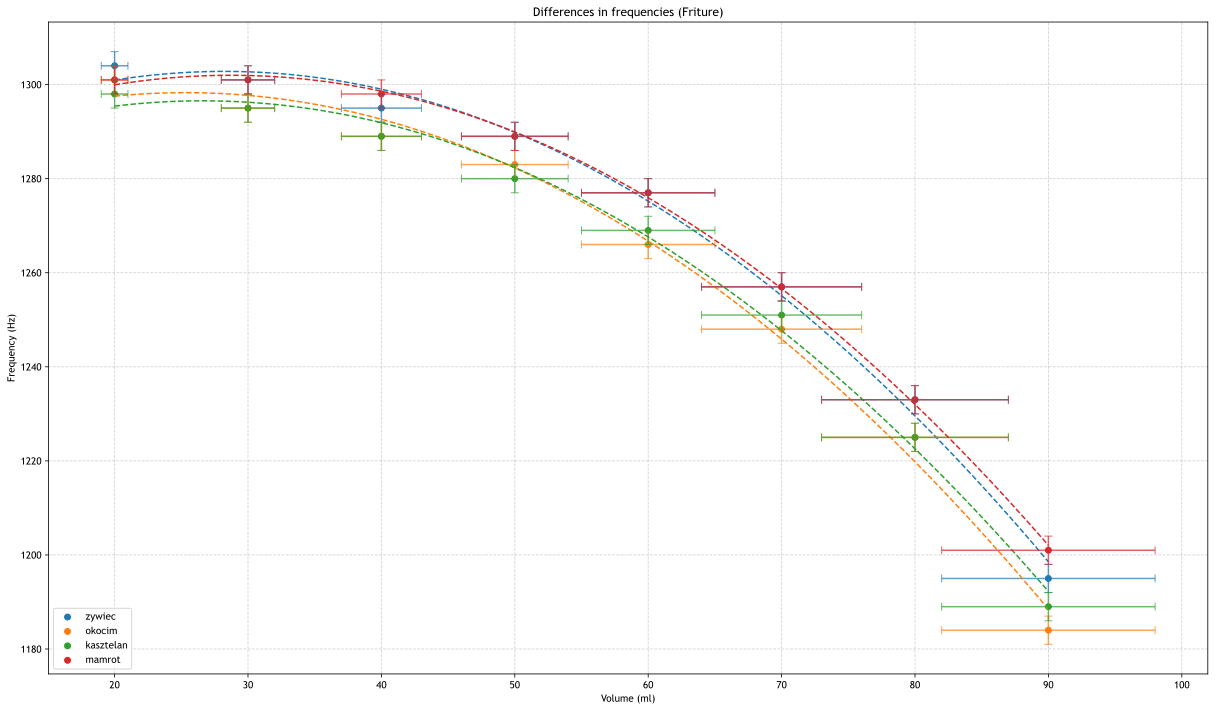

In [4]:
plt.figure(figsize=(17, 10))

plot_with_curve('zywiec', friture_kasztelan['volume'], friture_zywiec['frequencies'])
plot_with_curve('okocim', friture_okocim['volume'], friture_okocim['frequencies'])
plot_with_curve('kasztelan', friture_kasztelan['volume'], friture_kasztelan['frequencies'])
plot_with_curve('mamrot', friture_mamrot['volume'], friture_mamrot['frequencies'])


plt.title('Differences in frequencies (Friture)', loc='center')
plt.xlabel("Volume (ml)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

plt.legend(loc='lower left', prop={'size': 10}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()

## Reading sound files

### Analysis of the .wav files

In [5]:
DIR = os.path.join(os.getcwd(), "DIR")
beer_folders_dir = [d for d in os.listdir(DIR) if os.path.isdir(os.path.join(DIR, d))]

print(f"Found beer's folders: {beer_folders_dir}\n" + "-"*40)

Found beer's folders: ['Zywiec', 'Okocim-wisnia', 'Kasztelan', 'Mamrot']
----------------------------------------



Starts an analysis for: ZYWIEC
Loaded: zywiec-20_cut.wav | 384000 Hz | 1.47s
Loaded: zywiec-30_cut.wav | 384000 Hz | 1.08s
Loaded: zywiec-40_cut.wav | 384000 Hz | 1.33s
Loaded: zywiec-50_cut.wav | 384000 Hz | 1.44s
Loaded: zywiec-60_cut.wav | 384000 Hz | 1.34s
Loaded: zywiec-70_cut.wav | 384000 Hz | 1.46s
Loaded: zywiec-80_cut.wav | 384000 Hz | 1.29s
Loaded: zywiec-90_cut.wav | 384000 Hz | 1.43s


frequencies,volume
1303.445234,20
1301.056780,30
1294.209896,40
1288.276156,50
1277.065594,60
1257.468076,70
1231.938610,80
1196.499835,90


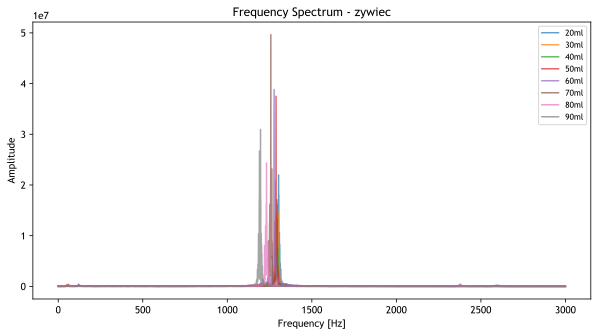


Starts an analysis for: OKOCIM-WISNIA
Loaded: okocim-wisnia-20_cut.wav | 44100 Hz | 1.49s
Loaded: okocim-wisnia-30_cut.wav | 44100 Hz | 1.24s
Loaded: okocim-wisnia-40_cut.wav | 384000 Hz | 1.77s
Loaded: okocim-wisnia-50_cut.wav | 384000 Hz | 2.27s
Loaded: okocim-wisnia-60_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-70_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-80_cut.wav | 44100 Hz | 1.54s
Loaded: okocim-wisnia-90_cut.wav | 44100 Hz | 1.20s


frequencies,volume
1295.838266,20
1295.349731,30
1288.738682,40
1277.449804,50
1267.308339,60
1247.195858,70
1218.863810,80
1180.951930,90


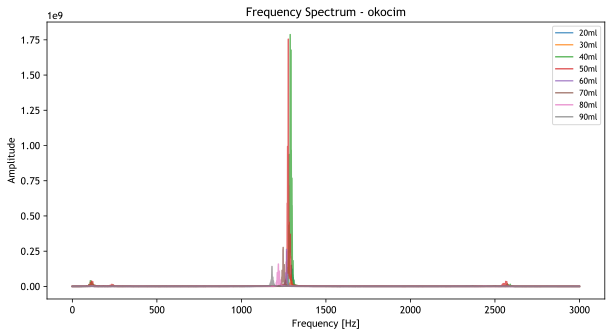


Starts an analysis for: KASZTELAN
Loaded: kasztelan-20_cut.wav | 384000 Hz | 1.10s
Loaded: kasztelan-30_cut.wav | 384000 Hz | 1.05s
Loaded: kasztelan-40_cut.wav | 384000 Hz | 1.02s
Loaded: kasztelan-50_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-60_cut.wav | 384000 Hz | 1.00s
Loaded: kasztelan-70_cut.wav | 384000 Hz | 0.99s
Loaded: kasztelan-80_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-90_cut.wav | 384000 Hz | 1.27s


frequencies,volume
1297.918894,20
1294.709578,30
1289.719341,40
1279.874931,50
1268.994033,60
1249.347063,70
1224.307054,80
1188.523735,90


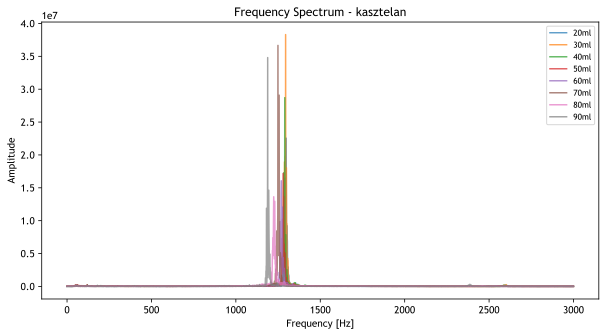


Starts an analysis for: MAMROT
Loaded: mamrot-20_cut.wav | 384000 Hz | 1.45s
Loaded: mamrot-30_cut.wav | 384000 Hz | 1.23s
Loaded: mamrot-40_cut.wav | 384000 Hz | 1.01s
Loaded: mamrot-50_cut.wav | 384000 Hz | 1.22s
Loaded: mamrot-60_cut.wav | 384000 Hz | 1.17s
Loaded: mamrot-70_cut.wav | 384000 Hz | 1.50s
Loaded: mamrot-80_cut.wav | 384000 Hz | 1.40s
Loaded: mamrot-90_cut.wav | 384000 Hz | 1.51s


frequencies,volume
1303.007374,20
1294.856604,30
1294.511830,40
1287.159103,50
1276.800192,60
1258.182160,70
1234.566066,80
1200.540691,90


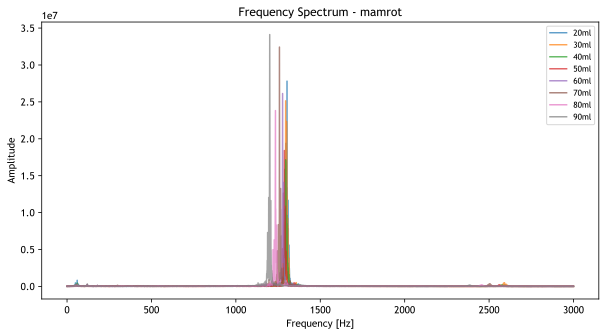

In [6]:
all_results_wav = []

for beer in beer_folders_dir:
    print(f"\nStarts an analysis for: {beer.upper()}")
    folder_path = os.path.join(DIR, beer)
    
    recordings = load_all(folder_path)
    
    if not recordings:
        print(f"Skipped {beer} - no audio files found.")
        continue
        
    beer_res, fft_data = dominant_frequencies(recordings)

    all_results_wav.append(beer_res)
    display(beer_res.drop(columns='Beer').style.hide(axis='index').set_caption(f"Results for {beer_res['Beer'].iloc[0]}:"))
    plot_spectrum(fft_data, beer_res)

### Analysis of the .m4a files

In [7]:
NOTEBOOK_DIR = os.path.join(os.getcwd(), "NOTEBOOK_DIR")
beer_folders = [d for d in os.listdir(NOTEBOOK_DIR) if os.path.isdir(os.path.join(NOTEBOOK_DIR, d))]

print(f"Found beer's folders: {beer_folders}\n" + "-"*40)

#['Zywiec', 'Okocim-wisnia', 'Kasztelan', 'Mamrot']

Found beer's folders: ['Zywiec', 'Okocim-wisnia', 'Kasztelan', 'Mamrot']
----------------------------------------



Starts an analysis for: ZYWIEC
Loaded: zywiec-20.m4a | 48000 Hz | 10.94s
Loaded: zywiec-30.m4a | 48000 Hz | 12.73s
Loaded: zywiec-40.m4a | 48000 Hz | 10.52s
Loaded: zywiec-50.m4a | 48000 Hz | 12.39s
Loaded: zywiec-60.m4a | 48000 Hz | 10.35s
Loaded: zywiec-70.m4a | 48000 Hz | 10.69s
Loaded: zywiec-80.m4a | 48000 Hz | 11.03s
Loaded: zywiec-90.m4a | 48000 Hz | 11.20s


frequencies,volume
1297.215791,20
1294.969113,30
1294.313427,40
1288.676708,50
1276.710916,60
1257.735496,70
1232.227058,80
1196.213835,90


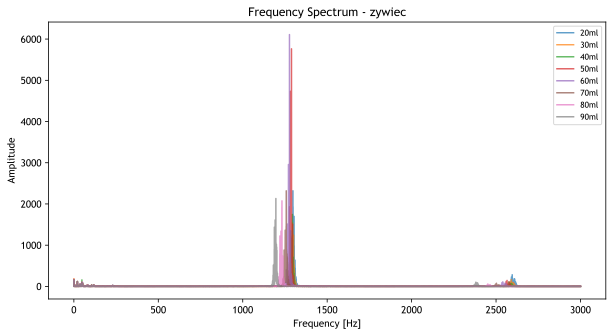


Starts an analysis for: OKOCIM-WISNIA
Loaded: okocim-wisnia-20.m4a | 48000 Hz | 10.43s
Loaded: okocim-wisnia-30.m4a | 48000 Hz | 12.99s
Loaded: okocim-wisnia-40.m4a | 48000 Hz | 11.03s
Loaded: okocim-wisnia-50.m4a | 48000 Hz | 13.25s
Loaded: okocim-wisnia-60.m4a | 48000 Hz | 13.50s
Loaded: okocim-wisnia-70.m4a | 48000 Hz | 10.52s
Loaded: okocim-wisnia-80.m4a | 48000 Hz | 12.05s
Loaded: okocim-wisnia-90.m4a | 48000 Hz | 14.36s


frequencies,volume
1295.410968,20
1293.390126,30
1293.797606,40
1279.114243,50
1266.046213,60
1247.527577,70
1218.055095,80
1178.461967,90


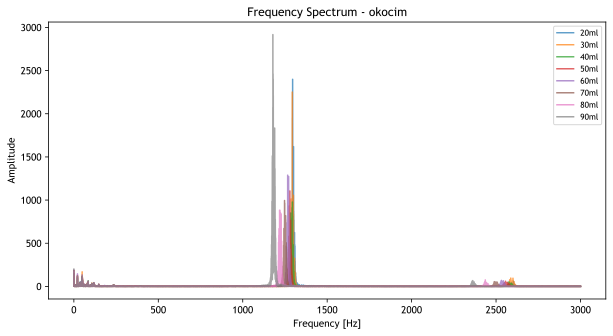


Starts an analysis for: KASZTELAN
Loaded: kasztelan-20.m4a | 48000 Hz | 10.09s
Loaded: kasztelan-30.m4a | 48000 Hz | 10.60s
Loaded: kasztelan-40.m4a | 48000 Hz | 11.45s
Loaded: kasztelan-50.m4a | 48000 Hz | 10.43s
Loaded: kasztelan-60.m4a | 48000 Hz | 10.86s
Loaded: kasztelan-70.m4a | 48000 Hz | 12.65s
Loaded: kasztelan-80.m4a | 48000 Hz | 10.17s
Loaded: kasztelan-90.m4a | 48000 Hz | 10.60s


frequencies,volume
1298.301837,20
1295.025783,30
1290.565708,40
1281.605522,50
1268.359327,60
1249.393907,70
1224.413576,80
1194.755377,90


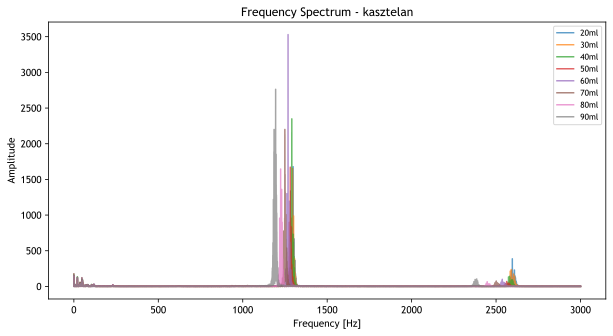


Starts an analysis for: MAMROT
Loaded: mamrot-20.m4a | 48000 Hz | 10.26s
Loaded: mamrot-30.m4a | 48000 Hz | 11.28s
Loaded: mamrot-40.m4a | 48000 Hz | 10.60s
Loaded: mamrot-50.m4a | 48000 Hz | 10.69s
Loaded: mamrot-60.m4a | 48000 Hz | 9.92s
Loaded: mamrot-70.m4a | 48000 Hz | 10.69s
Loaded: mamrot-80.m4a | 48000 Hz | 10.69s
Loaded: mamrot-90.m4a | 48000 Hz | 10.94s


frequencies,volume
1296.978558,20
1295.019497,30
1290.120740,40
1282.439177,50
1269.928754,60
1251.746725,70
1227.136619,80
1198.976483,90


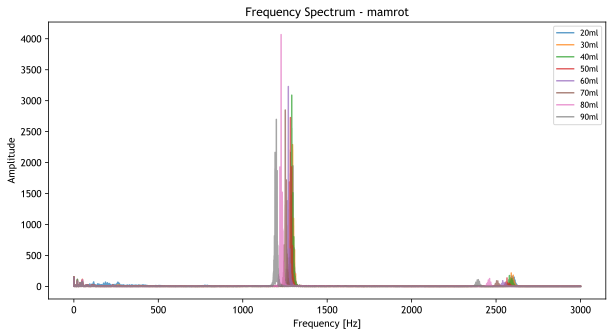

In [8]:
all_results_m4a = []

for beer in beer_folders:
    print(f"\nStarts an analysis for: {beer.upper()}")
    folder_path = os.path.join(NOTEBOOK_DIR, beer)
    
    recordings = load_all(folder_path)
    
    if not recordings:
        print(f"Skipped {beer} - no audio files found.")
        continue
        
    beer_res, fft_data = dominant_frequencies(recordings)

    all_results_m4a.append(beer_res)
    display(beer_res.drop(columns='Beer').style.hide(axis='index').set_caption(f"Results for {beer_res['Beer'].iloc[0]}:"))
    plot_spectrum(fft_data, beer_res)

#### Results

Plot of combined results

for .wav

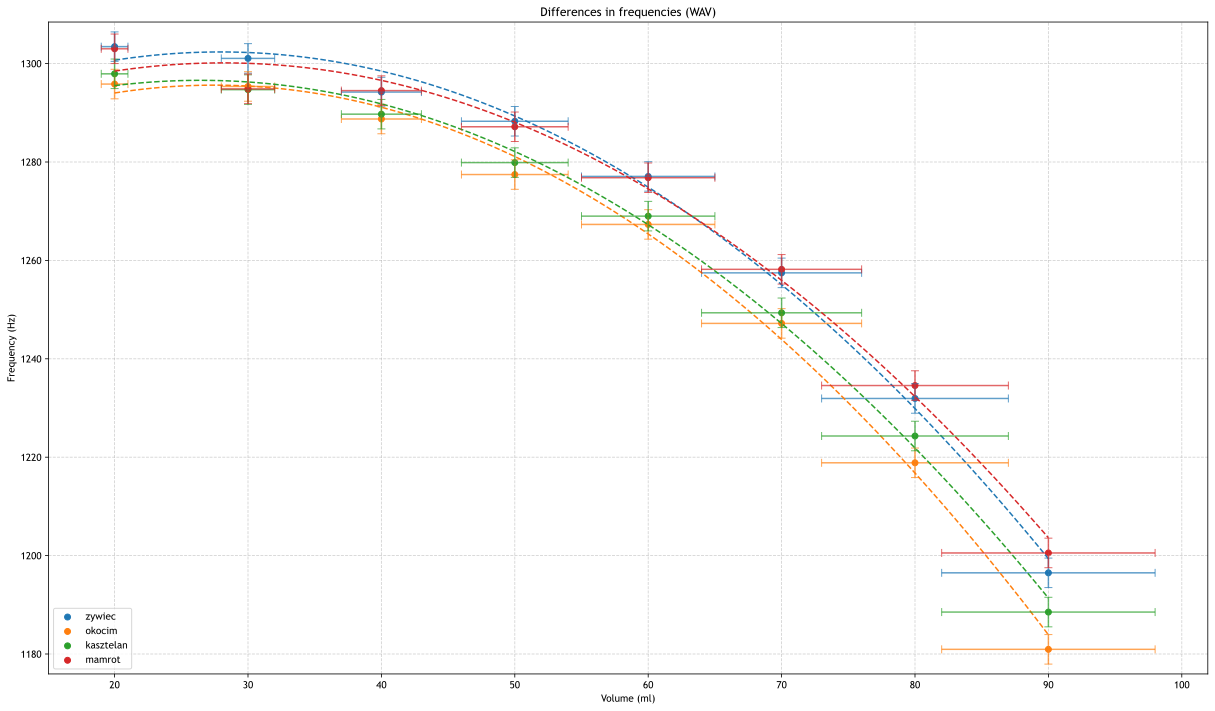

In [9]:
plt.figure(figsize=(17, 10))

for df in all_results_wav:
    beer_name = df['Beer'].iloc[0]
    volumes = df['volume']
    frequencies = df['frequencies']
    plot_with_curve(beer_name, volumes, frequencies)



plt.title('Differences in frequencies (WAV)', loc='center')
plt.xlabel("Volume (ml)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

f_min = [df['frequencies'].min() for df in all_results_wav]
f_max = [df['frequencies'].max() for df in all_results_wav]

plt.ylim(min(f_min)-5, max(f_max)+5) 
plt.legend(loc='lower left', prop={'size': 10}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()

for .m4a

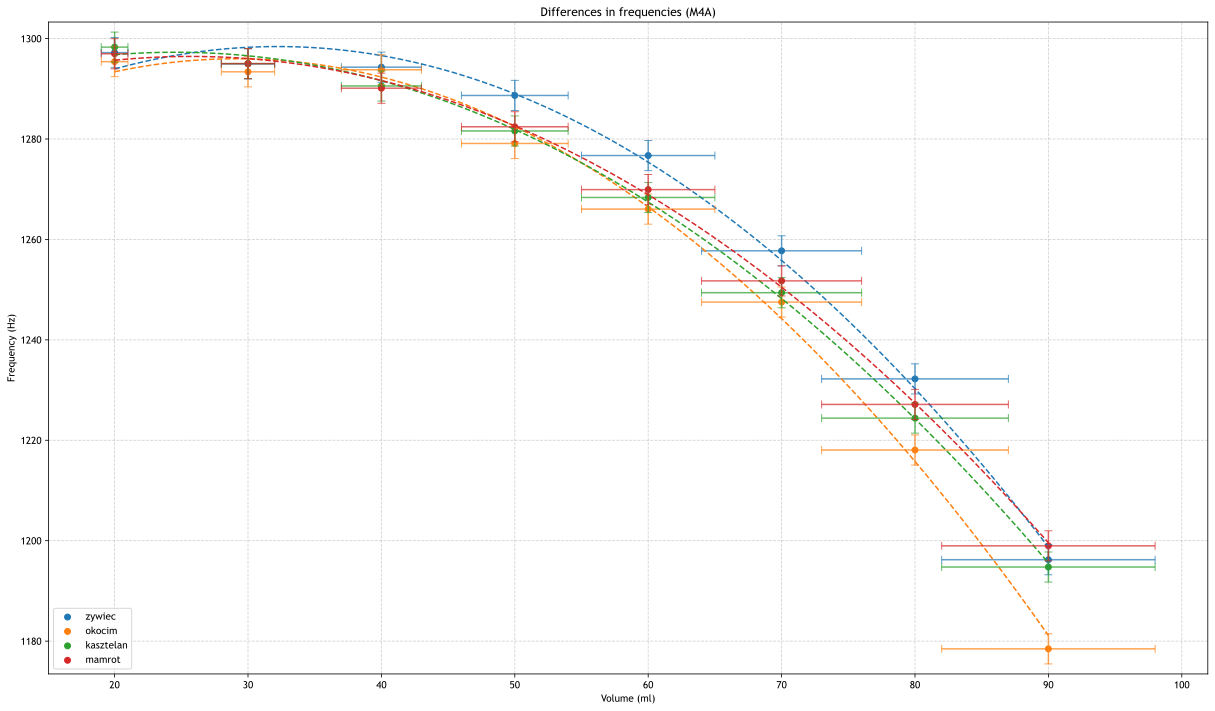

In [10]:
plt.figure(figsize=(17, 10))

for df in all_results_m4a:
    beer_name = df['Beer'].iloc[0]
    volumes = df['volume']
    frequencies = df['frequencies']
    plot_with_curve(beer_name, volumes, frequencies)


plt.title('Differences in frequencies (M4A)', loc='center')
plt.xlabel("Volume (ml)", loc='center')
plt.ylabel("Frequency (Hz)", loc='center')

f_min = [df['frequencies'].min() for df in all_results_m4a]
f_max = [df['frequencies'].max() for df in all_results_m4a]

plt.ylim(min(f_min)-5, max(f_max)+5) 
plt.legend(loc='lower left', prop={'size': 10}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
show_plot()